In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pygeostat as gs
import seaborn as sns
import missingno as msno


In [ ]:
gs.PlotStyle['font.size'] = 18
color_perm = 'darkorange'
color_poro = 'olive'
path = '18-FIGS/'


# Importing Data 

## PORO

In [ ]:
ppmt_poro_pca = gs.DataFile('07-Varcalc/poro_nscore2_vario.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_poro_pca.head(4)


,Unnamed: 0,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,...,NScore: PC11,NScore: PC12,NScore: PC2,NScore: PC3,NScore: PC4,NScore: PC5,NScore: PC6,NScore: PC7,NScore: PC8,NScore: PC9
0,0.0,15.579,61.537,0.0,-1.760797,-0.056214,2.658517,0.513909,-0.844122,-1.256827,...,0.000000,-0.727913,-0.167894,1.833915,0.340695,-0.524401,-1.281552,-1.833915,0.727913,0.524401
1,1.0,16.372,18.749,0.0,-0.883121,0.780030,-0.902054,-3.427588,1.950106,-1.697072,...,-0.524401,-0.967422,0.524401,-0.340695,-1.833915,1.833915,-1.833915,-0.167894,-0.967422,0.000000
2,2.0,17.692,86.628,0.0,-0.004501,3.361060,-0.582820,1.583066,-0.908772,-0.327229,...,0.340695,-0.340695,1.281552,-0.167894,1.281552,-0.727913,-0.340695,0.000000,-0.524401,-0.967422
3,3.0,22.975,41.992,0.0,0.521334,1.414758,1.166385,-1.298540,0.186838,0.028080,...,1.833915,0.727913,0.967422,0.967422,-0.967422,0.340695,0.000000,1.833915,1.833915,-0.340695


## PERM

In [ ]:
ppmt_perm_pca = gs.DataFile('07-Varcalc/perm_nscore2_vario.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_perm_pca.head(4)


,Unnamed: 0,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,...,NScore: PC11,NScore: PC12,NScore: PC2,NScore: PC3,NScore: PC4,NScore: PC5,NScore: PC6,NScore: PC7,NScore: PC8,NScore: PC9
0,0.0,15.579,61.537,0.0,-2.037290,-2.816031,0.586629,-2.163039,0.137466,0.936337,...,-1.281552,1.281552,-0.967422,0.340695,-1.833915,0.167894,0.727913,-1.833915,1.281552,0.524401
1,1.0,16.372,18.749,0.0,7.245091,-2.034488,0.041810,-1.504417,1.845318,0.864331,...,-0.340695,-0.967422,-0.727913,0.000000,-0.727913,1.281552,0.524401,1.281552,0.167894,-1.833915
2,2.0,17.692,86.628,0.0,-2.285403,-3.473820,1.285614,1.280568,0.089249,-2.921014,...,-0.524401,0.340695,-1.281552,0.967422,0.727913,0.000000,-1.833915,0.000000,0.000000,-0.967422
3,3.0,22.975,41.992,0.0,6.143209,-1.249426,1.018325,-1.919681,-1.017644,-1.375874,...,0.524401,0.000000,-0.340695,0.727913,-1.281552,-0.727913,-1.281552,-0.340695,-1.833915,1.281552


#### Data Spacing

In [ ]:
ppmt_poro_pca.spacing(n_nearest=4)
ppmt_poro_pca.data.head(3)


,Unnamed: 0,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,...,NScore: PC12,NScore: PC2,NScore: PC3,NScore: PC4,NScore: PC5,NScore: PC6,NScore: PC7,NScore: PC8,NScore: PC9,Data Spacing (m)
0,0.0,15.579,61.537,0.0,-1.760797,-0.056214,2.658517,0.513909,-0.844122,-1.256827,...,-0.727913,-0.167894,1.833915,0.340695,-0.524401,-1.281552,-1.833915,0.727913,0.524401,24.507378
1,1.0,16.372,18.749,0.0,-0.883121,0.780030,-0.902054,-3.427588,1.950106,-1.697072,...,-0.967422,0.524401,-0.340695,-1.833915,1.833915,-1.833915,-0.167894,-0.967422,0.000000,37.993937
2,2.0,17.692,86.628,0.0,-0.004501,3.361060,-0.582820,1.583066,-0.908772,-0.327229,...,-0.340695,1.281552,-0.167894,1.281552,-0.727913,-0.340695,0.000000,-0.524401,-0.967422,25.820423


# PORO

## PC1 Variogram

In [ ]:
lagdist_xy = ppmt_poro_pca['Data Spacing (m)'].values.min()
lagtol_xy = lagdist_xy * 0.5

x_range = np.ptp(ppmt_poro_pca[ppmt_poro_pca.x].values)
y_range = np.ptp(ppmt_poro_pca[ppmt_poro_pca.y].values)
n_lag_x =  np.ceil((x_range * 0.5) /  lagdist_xy)
n_lag_y =  np.ceil((y_range * 0.5) /  lagdist_xy)
print(f'X range is {x_range}')
print(f'Y range is {y_range}')


X range is 72.37
Y range is 70.257


In [ ]:
varcalc = gs.Program(program='04-GSlib/varcalc')


In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC1')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC1_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC1'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           17
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC1_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc1 = gs.DataFile('07-Varcalc/varcalc_PC1_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc1, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
varmodel = gs.Program(program='04-GSlib/varmodel')


In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 58


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC1_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
06-Varcalc/varcalc_PC1_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC1_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC1_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 06-Varcalc/varcalc_PC1_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC1_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc1 = gs.DataFile('08-Varmodel/varcalc_PC1_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc1, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], title = 'PC1 Omnidirecional PORO', label='Experimental')
gs.variogram_plot(model_varg_pc1, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, title = 'PC1 Omnidirecional PORO', color=color_poro, ylim=[0, 1.2], label='Model')


<Axes: title={'center': 'PC1 Omnidirecional PORO'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC2 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC2')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC2_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC2'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           21
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC2_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc2 = gs.DataFile('07-Varcalc/varcalc_PC2_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc2, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC2 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC2 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 35


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC2_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
3    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC2_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC2_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']



varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC2_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC2_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC2_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc2 = gs.DataFile('08-Varmodel/varcalc_PC2_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc2, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc2, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC3 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC3')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC3_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC3'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           22
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC3_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc3 = gs.DataFile('07-Varcalc/varcalc_PC3_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc3, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 20


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC3_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC3_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC3_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC3_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC3_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC3_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc3 = gs.DataFile('08-Varmodel/varcalc_PC3_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc3, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc3, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC4 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC4')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC4_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC4'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           23
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC4_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc4 = gs.DataFile('07-Varcalc/varcalc_PC4_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc4, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC4 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC4 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 13


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC4_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC4_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC4_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC4_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC4_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC4_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc4 = gs.DataFile('08-Varmodel/varcalc_PC4_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc4, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc4, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC5 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC5')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC5_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC5'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           24
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC5_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377715     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc5 = gs.DataFile('07-Varcalc/varcalc_PC5_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc5, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 37


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC5_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
3    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC5_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC5_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']



varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC5_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC5_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC5_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc5 = gs.DataFile('08-Varmodel/varcalc_PC5_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc5, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc5, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC 6 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC6')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC6_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC6'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           25
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC6_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc6 = gs.DataFile('07-Varcalc/varcalc_PC6_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc6, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc1 = 0.85
h_max1 = 25
cc2 = 1 - (cc1 + ne)
h_max2 = 25


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC6_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
2    {ne}                   -nst, nugget effect
3    {cc1}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max1}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
1    {cc2}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
     {h_max2}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC6_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC6_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']



varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC6_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           2
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC6_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC6_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc6 = gs.DataFile('08-Varmodel/varcalc_PC6_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc6, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc6, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ppmt_poro_pca = gs.DataFile('07-Varcalc/poro_nscore2_vario.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_poro_pca.head(4)


,Unnamed: 0,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,...,NScore: PC11,NScore: PC12,NScore: PC2,NScore: PC3,NScore: PC4,NScore: PC5,NScore: PC6,NScore: PC7,NScore: PC8,NScore: PC9
0,0.0,15.579,61.537,0.0,-1.760797,-0.056214,2.658517,0.513909,-0.844122,-1.256827,...,0.000000,-0.727913,-0.167894,1.833915,0.340695,-0.524401,-1.281552,-1.833915,0.727913,0.524401
1,1.0,16.372,18.749,0.0,-0.883121,0.780030,-0.902054,-3.427588,1.950106,-1.697072,...,-0.524401,-0.967422,0.524401,-0.340695,-1.833915,1.833915,-1.833915,-0.167894,-0.967422,0.000000
2,2.0,17.692,86.628,0.0,-0.004501,3.361060,-0.582820,1.583066,-0.908772,-0.327229,...,0.340695,-0.340695,1.281552,-0.167894,1.281552,-0.727913,-0.340695,0.000000,-0.524401,-0.967422
3,3.0,22.975,41.992,0.0,0.521334,1.414758,1.166385,-1.298540,0.186838,0.028080,...,1.833915,0.727913,0.967422,0.967422,-0.967422,0.340695,0.000000,1.833915,1.833915,-0.340695


## PC7 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC7')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC7_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC7'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           26
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC7_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc7 = gs.DataFile('07-Varcalc/varcalc_PC7_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc7, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 34


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC7_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
06-Varcalc/varcalc_PC7_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC7_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC7_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 06-Varcalc/varcalc_PC7_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC7_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc7 = gs.DataFile('08-Varmodel/varcalc_PC7_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc7, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc7, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC8 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC8')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC8_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC8'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           27
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC8_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc8 = gs.DataFile('07-Varcalc/varcalc_PC8_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc8, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC8 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC8 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc1 = 1 - ne
h_max1 = 24
#cc2 = 1 - (ne + cc1)
#h_max2 = 25


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC8_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc1}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max1}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC8_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC8_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC8_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC8_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC8_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc8 = gs.DataFile('08-Varmodel/varcalc_PC8_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc8, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc8, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC9 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC9')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC9_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC9'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           28
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC9_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc9 = gs.DataFile('07-Varcalc/varcalc_PC9_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc9, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC9 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC9 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 24


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC9_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC9_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC9_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC9_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC9_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC9_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc9 = gs.DataFile('08-Varmodel/varcalc_PC9_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc9, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc9, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC10 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC10')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC10_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC10'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           18
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC10_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up fina

In [ ]:
exp_varg_pc10 = gs.DataFile('07-Varcalc/varcalc_PC10_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc10, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC10 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC10 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 25


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC10_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC10_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC10_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC10_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC10_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC10_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc10 = gs.DataFile('08-Varmodel/varcalc_PC10_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc10, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.4], label='Experimental')
gs.variogram_plot(model_varg_pc10, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.4], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC11 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC11')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC11_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC11'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           19
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC11_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up fina

In [ ]:
exp_varg_pc11 = gs.DataFile('07-Varcalc/varcalc_PC11_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc11, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC11 Omnidirecional',
                  figsize=(6, 4)
                 )


c:\Users\Bernardo.Silveira\AppData\Local\anaconda3\Lib\site-packages\pygeostat\plotting\utils.py:614: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


<Axes: title={'center': 'PC11 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 28


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC11_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
3    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC11_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC11_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC11_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC11_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC11_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc11 = gs.DataFile('08-Varmodel/varcalc_PC11_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc11, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc11, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC12 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_poro_pca}                -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_poro_pca.gscol('NScore: PC12')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC12_poro.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_poro_pca['NScore: PC12'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/poro_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           20
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC12_poro.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up fina

In [ ]:
exp_varg_pc12 = gs.DataFile('07-Varcalc/varcalc_PC12_poro.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc12, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC12 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC12 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 19


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC12_ptns_poro.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC12_poro.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC12_fit_poro.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC12_ptns_poro.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC12_poro.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC12_fit_poro.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc12 = gs.DataFile('08-Varmodel/varcalc_PC12_ptns_poro.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc12, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.4], label='Experimental')
gs.variogram_plot(model_varg_pc12, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.4], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
exp_vargs = [exp_varg_pc1, exp_varg_pc2, exp_varg_pc3, exp_varg_pc4, exp_varg_pc5, exp_varg_pc6,
             exp_varg_pc7, exp_varg_pc8, exp_varg_pc9, exp_varg_pc10, exp_varg_pc11, exp_varg_pc12]
model_vargs = [model_varg_pc1, model_varg_pc2, model_varg_pc3, model_varg_pc4, model_varg_pc5, model_varg_pc6, 
              model_varg_pc7, model_varg_pc8, model_varg_pc9, model_varg_pc10, model_varg_pc11, model_varg_pc12]


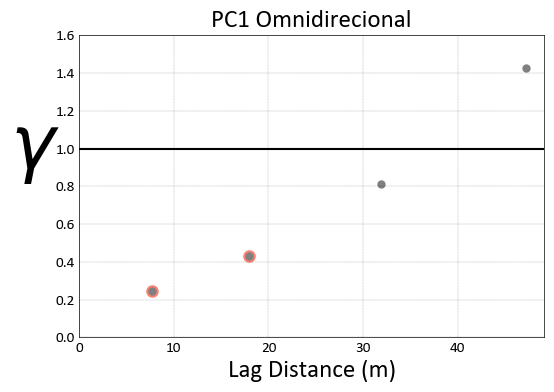

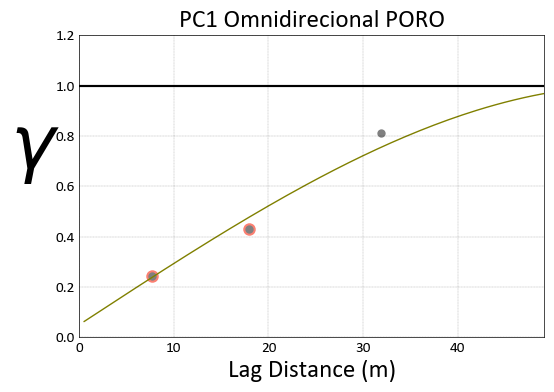

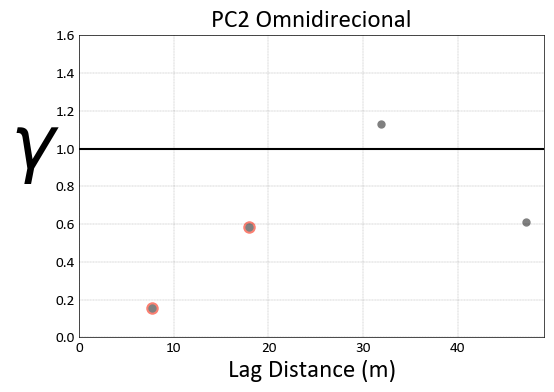

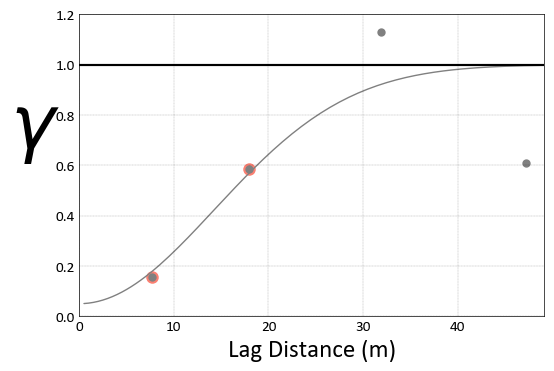

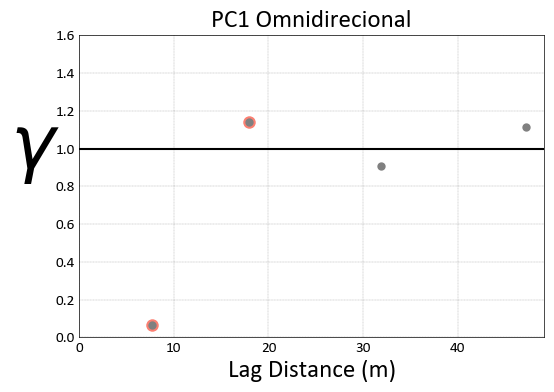

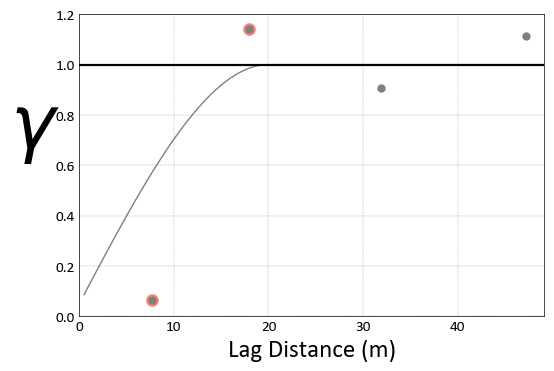

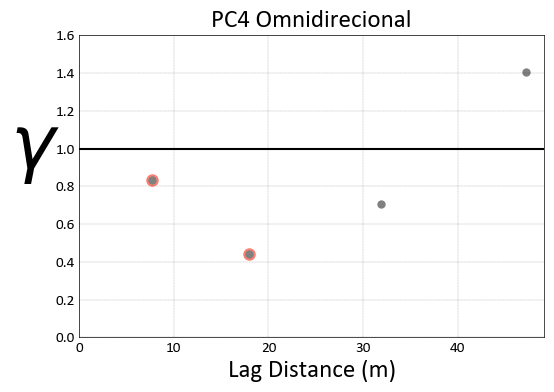

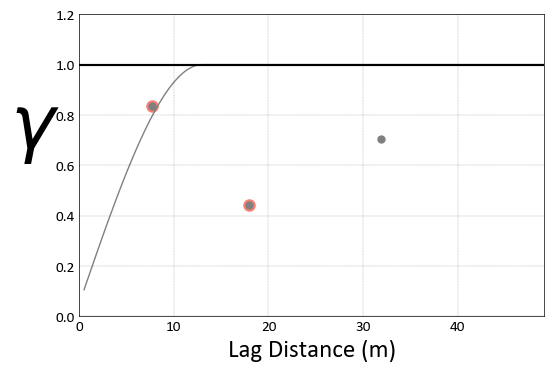

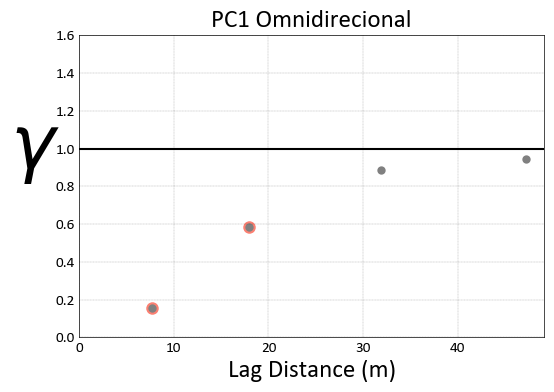

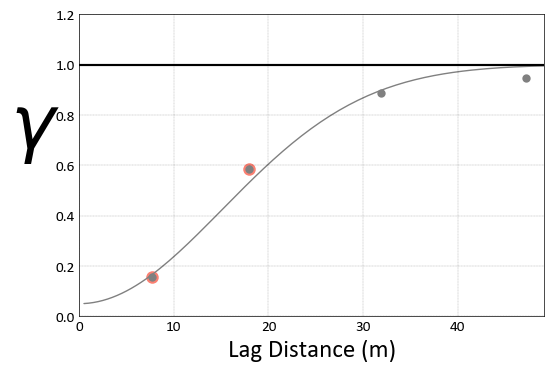

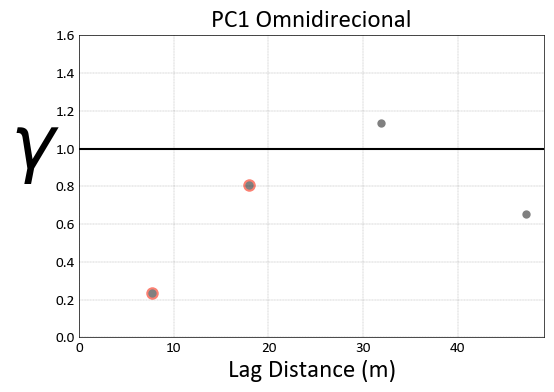

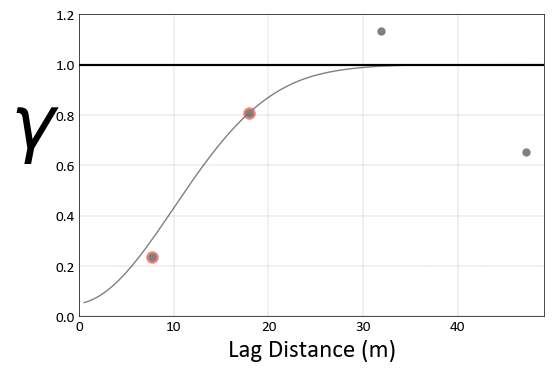

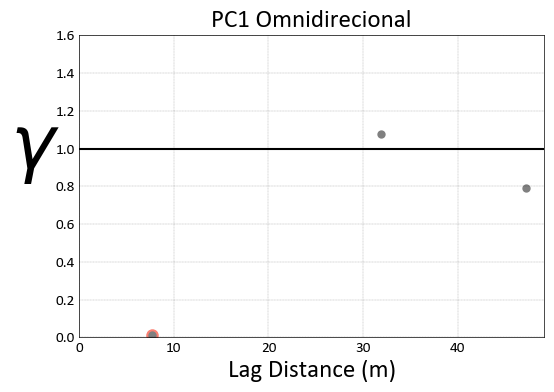

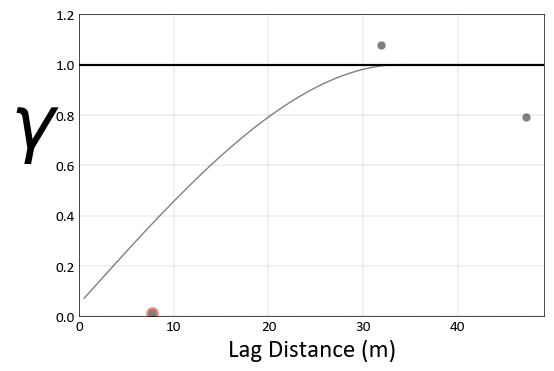

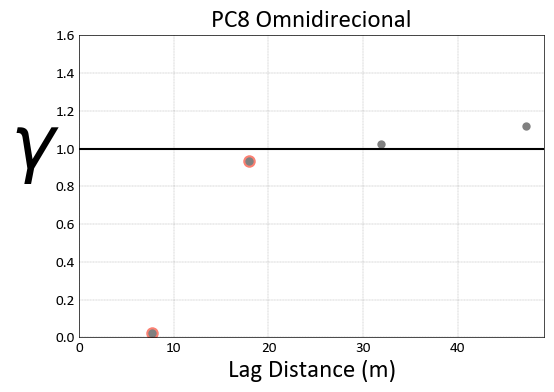

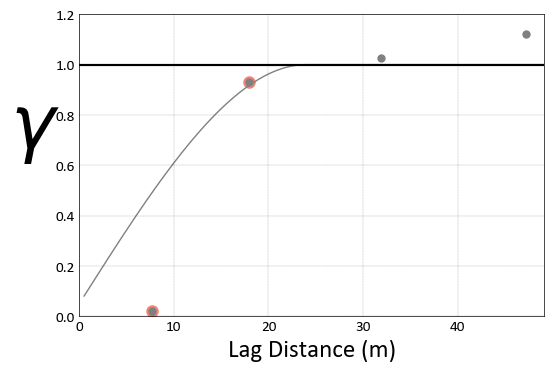

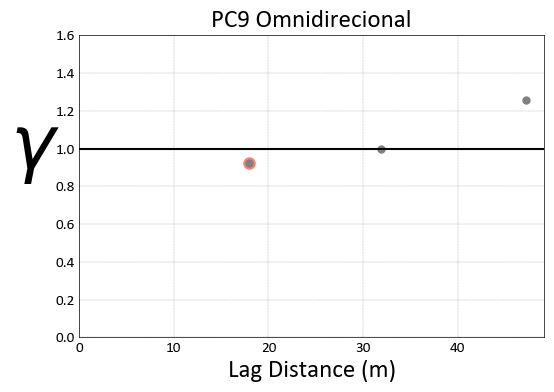

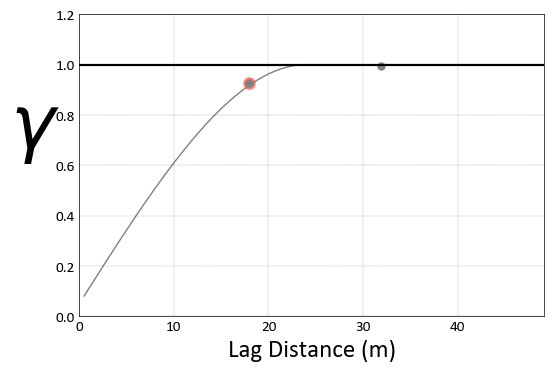

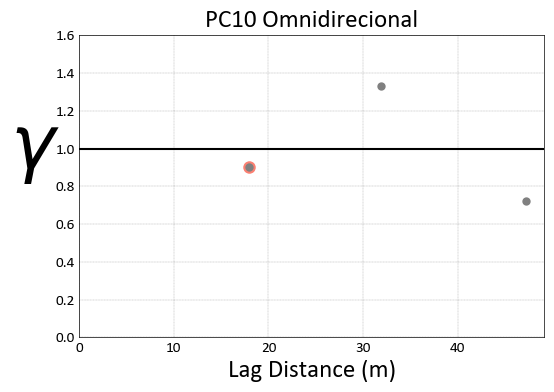

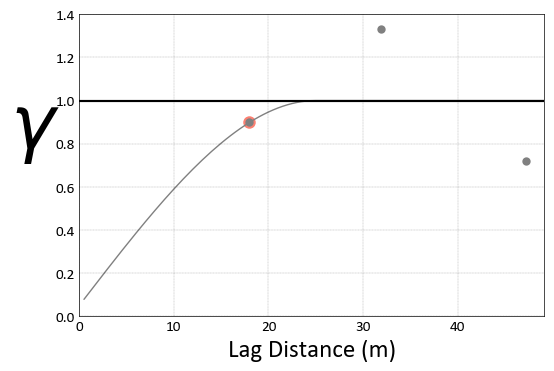

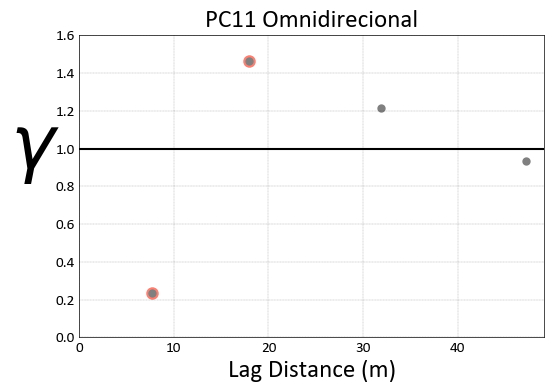

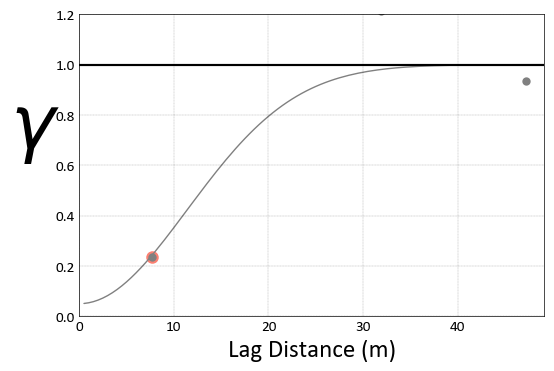

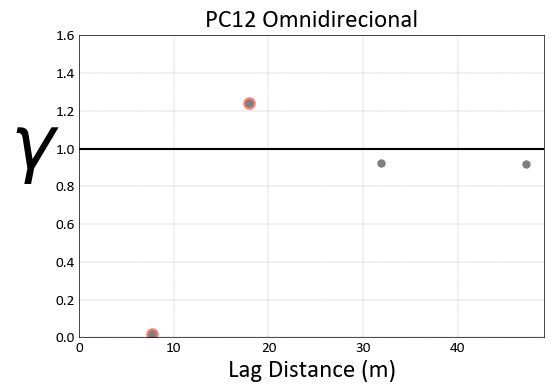

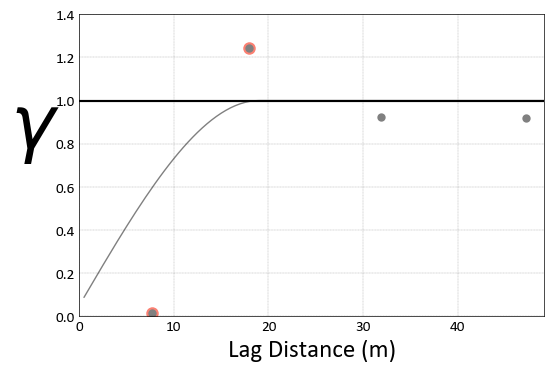

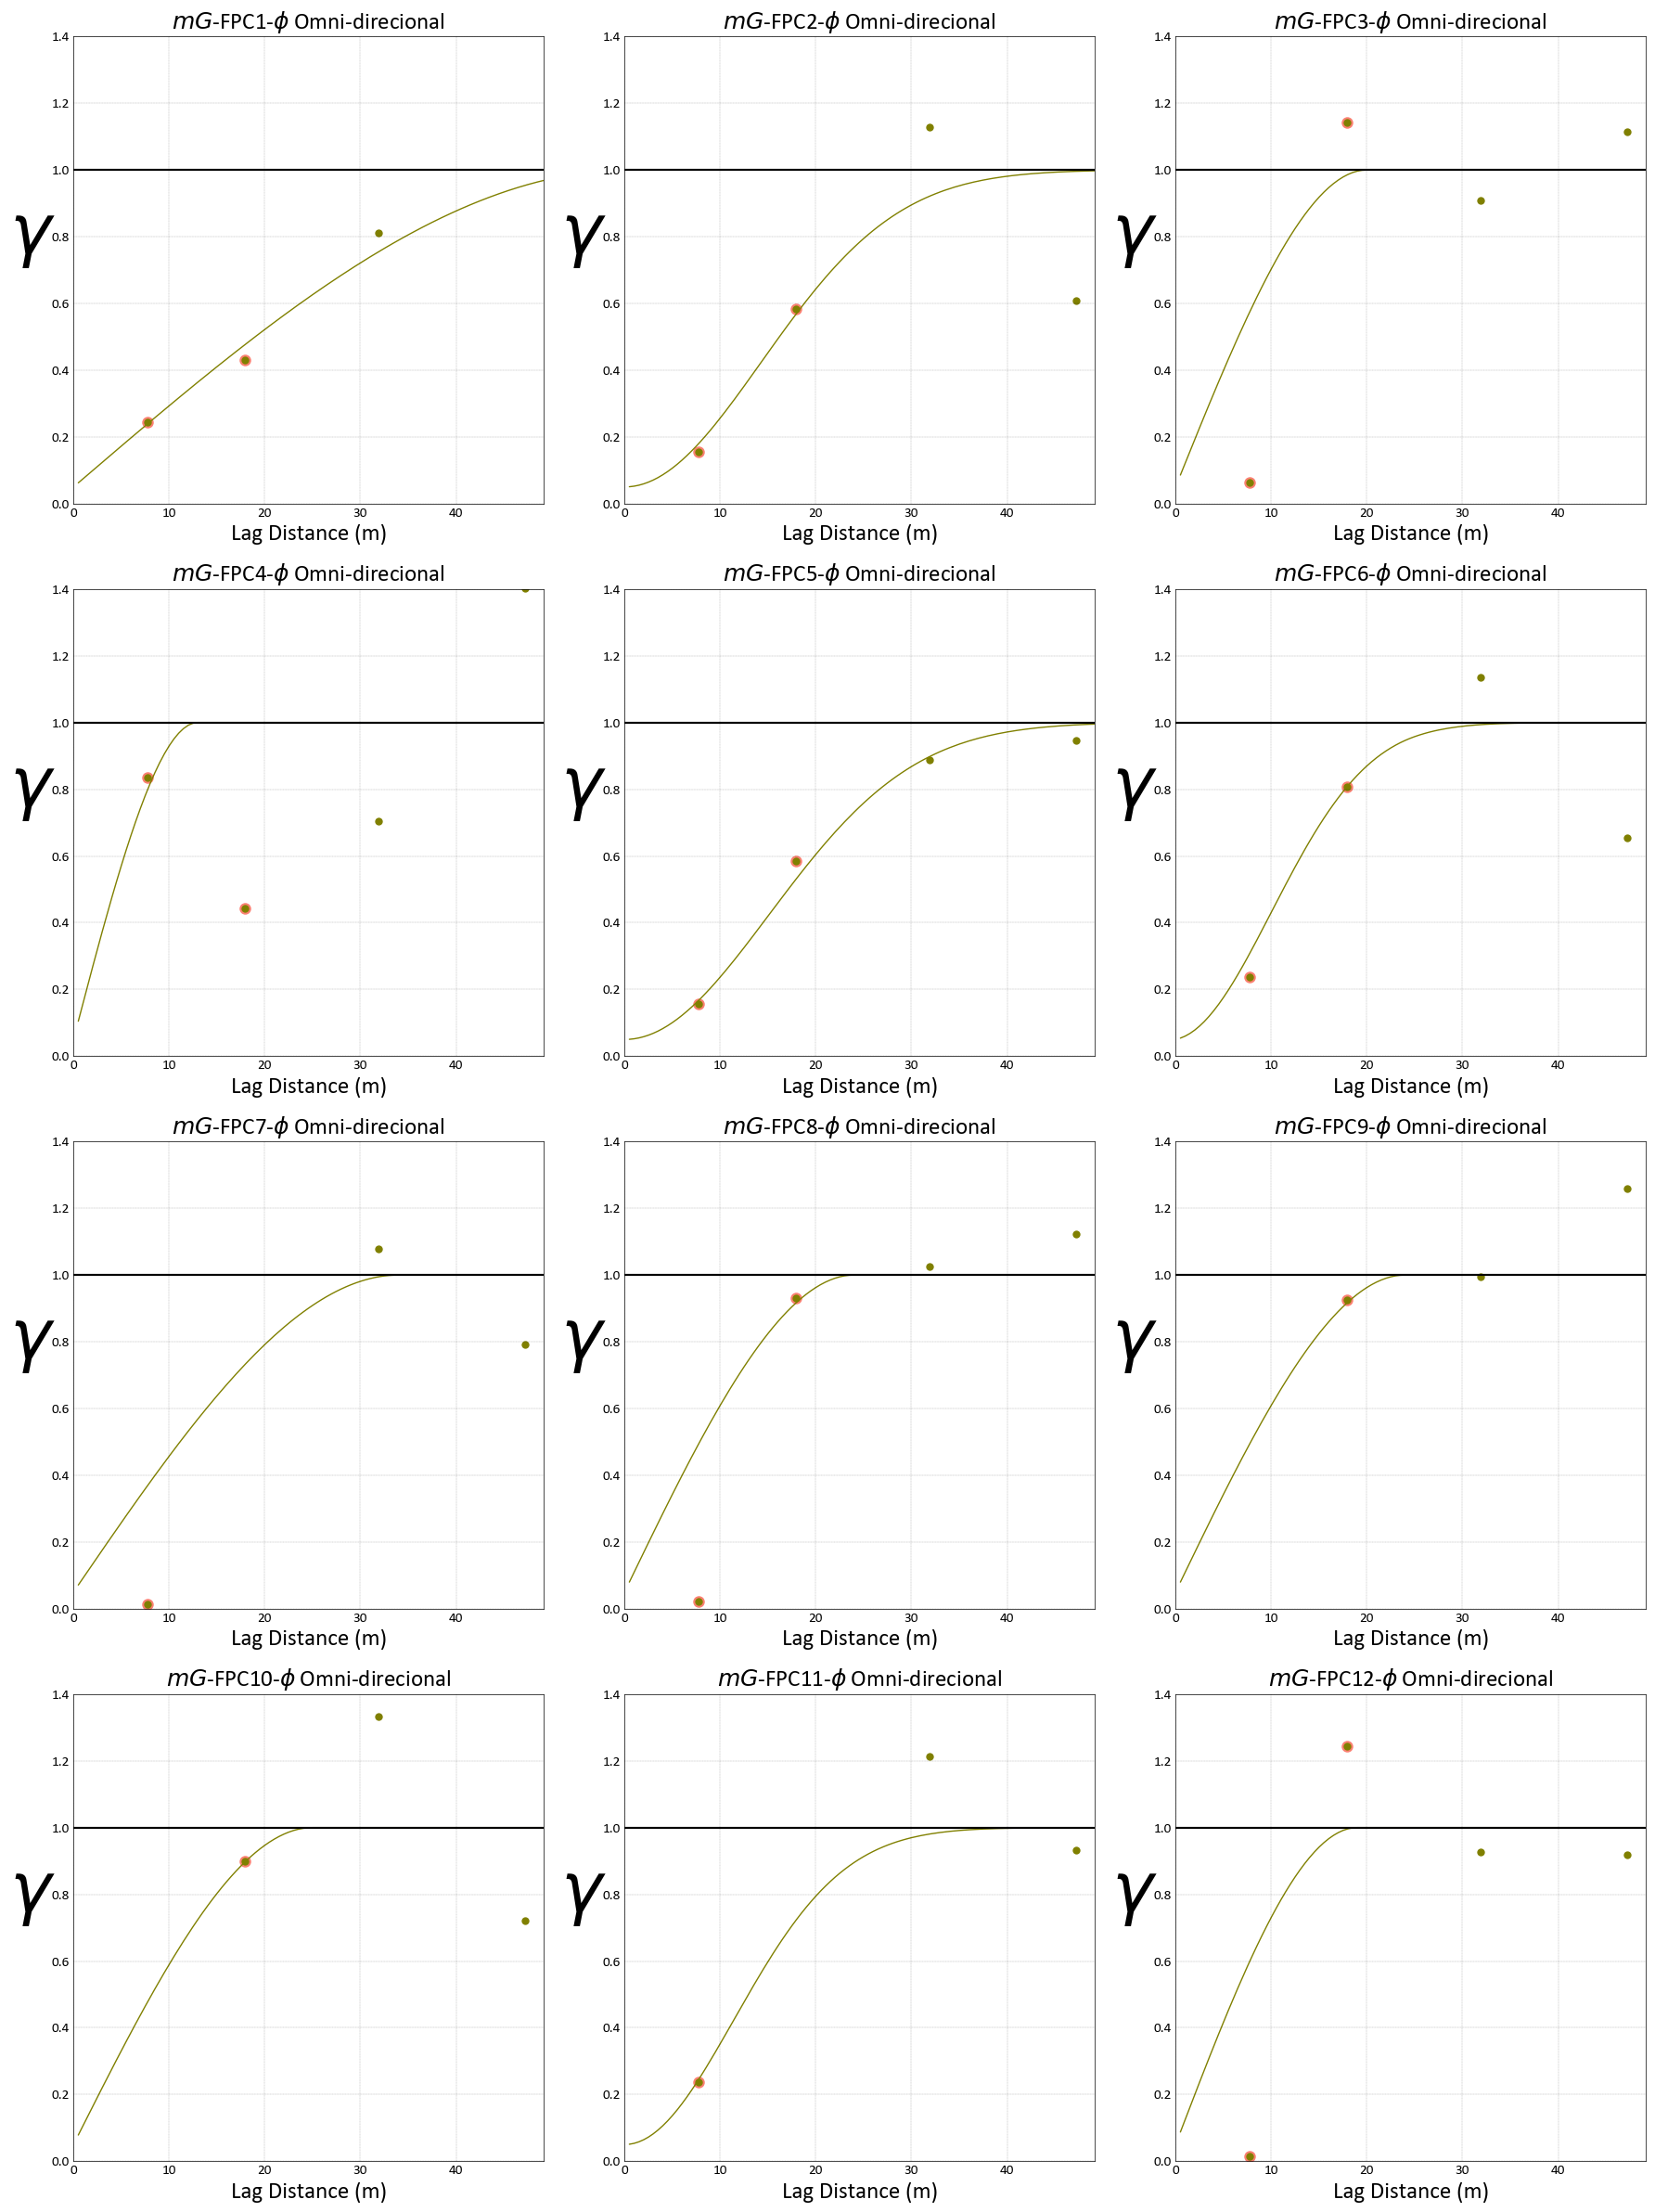

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(18, 24))  # Create a 4x3 subplot matrix



# Loop over PCs
for i in range(12):
    row = i // 3  # Calculate row index for current subplot
    col = i % 3   # Calculate column index for current subplot
    
    exp_varg = exp_vargs[i]      # Experimental variogram for current PC
    model_varg = model_vargs[i]  # Modeled variogram for current PC
    
    # Plot experimental variogram
    gs.variogram_plot(exp_varg, index=1, grid=True, sill=1, ylim=[0, 1.4], label='Experimental', 
                      title=f'$mG$-FPC{i+1} Omni-direcional', color=color_poro, ax=axs[row, col])
    
    # Plot modeled variogram
    gs.variogram_plot(model_varg, index=1, grid=True, sill=1, experimental=False, ylim=[0, 1.4], label='Model', 
                      title=f'$mG$-FPC{i+1}-$\phi$ Omni-direcional', color=color_poro, ax=axs[row, col])

plt.tight_layout()  
plt.savefig(f'{path}poro_vars.eps', format='eps', dpi=600)
plt.savefig(f'{path}poro_vars.tif', format='tiff', dpi=300)  
plt.show()          


# PERM

## PC1 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC1')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC1_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC1'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           17
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC1_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc1 = gs.DataFile('07-Varcalc/varcalc_PC1_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc1, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 55


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC1_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC1_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC1_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC1_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC1_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC1_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc1 = gs.DataFile('08-Varmodel/varcalc_PC1_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc1, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc1, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC2 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC2')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC2_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC2'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           21
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC2_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc2 = gs.DataFile('07-Varcalc/varcalc_PC2_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc2, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 50


In [ ]:
ne = 0.05
cc1 = 0.9
h_max1 = 50
cc2 = 1 - (ne + cc1)
h_max2 = 60


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC2_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
2    {ne}                   -nst, nugget effect
3    {cc1}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max1}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
1    {cc2}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max2}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC2_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC2_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC2_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           2
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC2_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC2_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc2 = gs.DataFile('08-Varmodel/varcalc_PC2_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc2, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc2, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC3 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC3')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC3_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC3'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           22
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC3_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc3 = gs.DataFile('07-Varcalc/varcalc_PC3_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc3, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 18


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC3_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC3_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC3_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC3_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC3_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC3_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc3 = gs.DataFile('08-Varmodel/varcalc_PC3_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc3, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc3, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.5], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC4 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC4')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC4_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC4'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           23
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC4_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc4 = gs.DataFile('07-Varcalc/varcalc_PC4_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc4, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC4 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC4 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 30


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC4_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
3    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC4_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC4_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC4_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC4_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC4_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc4 = gs.DataFile('08-Varmodel/varcalc_PC4_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc4, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc4, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.4], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC5 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC5')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC5_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC5'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           24
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC5_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc5 = gs.DataFile('07-Varcalc/varcalc_PC5_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc5, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 20


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC5_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC5_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC5_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC5_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC5_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC5_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc5 = gs.DataFile('08-Varmodel/varcalc_PC5_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc5, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc5, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC 6 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC6')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC6_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC6'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           25
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC6_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc6 = gs.DataFile('07-Varcalc/varcalc_PC6_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc6, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC1 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC1 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 20


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC6_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC6_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC6_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC6_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC6_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC6_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc6 = gs.DataFile('08-Varmodel/varcalc_PC6_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc6, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc6, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC7 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC7')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC7_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC7'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           26
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC7_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc7 = gs.DataFile('07-Varcalc/varcalc_PC7_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc7, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC7 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC7 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 40


In [ ]:
ne = 0.05
cc1 = 0.5
h_max1 = 35
cc2 = 1 - (ne + cc1)
h_max2 = 35


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC7_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
2    {ne}                   -nst, nugget effect
3    {cc1}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max1}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
1    {cc2}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max2}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC7_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC7_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC7_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           2
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC7_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC7_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc7 = gs.DataFile('08-Varmodel/varcalc_PC7_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc7, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc7, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC8 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC8')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC8_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC8'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           27
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC8_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc8 = gs.DataFile('07-Varcalc/varcalc_PC8_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc8, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC8 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC8 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 20


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC8_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC8_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC8_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC8_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC8_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC8_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc8 = gs.DataFile('08-Varmodel/varcalc_PC8_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc8, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.4], label='Experimental')
gs.variogram_plot(model_varg_pc8, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.4], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC9 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC9')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC9_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC9'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           28
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC9_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up final

In [ ]:
exp_varg_pc9 = gs.DataFile('07-Varcalc/varcalc_PC9_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc9, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC9 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC9 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 25


In [ ]:
ne = 0.05
cc1 = 0.15
h_max1 = 13
cc2 = 0.6
h_max2 = 27
cc3 = 1 - (ne + cc1 + cc2)
h_max3 = 41


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC9_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
3    {ne}                   -nst, nugget effect
1    {cc1}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max1}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
1    {cc2}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max2}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)      
1    {cc3}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max3}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)    
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC9_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC9_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC9_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           3
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC9_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC9_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc9 = gs.DataFile('08-Varmodel/varcalc_PC9_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc9, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc9, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.2], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC10 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC10')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC10_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC10'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           18
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC10_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up fina

In [ ]:
exp_varg_pc10 = gs.DataFile('07-Varcalc/varcalc_PC10_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc10, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC10 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC10 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.1
cc1 = 0.1
h_max1 = 36
cc2 = 1 - (cc1 + ne)
h_max2 = 41


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC10_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
2    {ne}                   -nst, nugget effect
1    {cc1}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max1}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
2    {cc2}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max2}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC10_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC10_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC10_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           2
 c0 constrained to  0.100000000000000       0.100000000000000     
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC10_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC10_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc10 = gs.DataFile('08-Varmodel/varcalc_PC10_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc10, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.2], label='Experimental')
gs.variogram_plot(model_varg_pc10, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.4], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC11 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC11')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC11_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC11'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           19
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC11_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up fina

In [ ]:
exp_varg_pc11 = gs.DataFile('07-Varcalc/varcalc_PC11_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc11, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC11 Omnidirecional',
                  figsize=(6, 4)
                 )


c:\Users\Bernardo.Silveira\AppData\Local\anaconda3\Lib\site-packages\pygeostat\plotting\utils.py:614: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


<Axes: title={'center': 'PC11 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 55


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC11_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC11_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC11_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']



varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC11_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC11_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC11_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc11 = gs.DataFile('08-Varmodel/varcalc_PC11_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc11, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.7], label='Experimental')
gs.variogram_plot(model_varg_pc11, index=1, ax=ax, grid=True, 
                  
                  sill=1, experimental=False, ylim=[0, 1.7], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

## PC12 Variogram

In [ ]:
parstr = f"""                  Parameters for VARCALC
                  **********************
 
START OF PARAMETERS:
{ppmt_perm_pca}                -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}                         -   columns for X, Y, Z coordinates
1   {ppmt_perm_pca.gscol('NScore: PC12')}                            -   number of variables,column numbers (position used for tail,head variables below)
-1.0e21    1.0e21                      -   trimming limits
1                                -number of directions
0.0 91.0 91.0 0.0 0.0 0 0.0   -Dir 01: azm,azmtol,bandhorz,dip,diptol,bandvert,tilt
 {n_lag_y}  {lagdist_xy}  {lagtol_xy}                 -        number of lags,lag distance,lag tolerance
07-Varcalc/varcalc_PC12_perm.out                       -file for experimental variogram points output.
0                                 -legacy output (0=no, 1=write out gamv2004 format)
1                                 -run checks for common errors
1                                 -standardize sills? (0=no, 1=yes)
1                                 -number of variogram types
1   1   1   {ppmt_perm_pca['NScore: PC12'].var()}                     -tail variable, head variable, variogram type (and cutoff/category), sill
1   2   2   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
2   2   1   ?                     -tail variable, head variable, variogram type (and cutoff/category), sill
"""

varcalc.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varcalc', 'temp']

varcalc version:  1.400

  data file: 07-Varcalc/perm_nscore2_vario.out
  x,y,z columns:            2           3           4
  number of variables:            1
  Variable columns:           20
  tmin,tmax:  -1.000000000000000E+021  1.000000000000000E+021
  number of directions:            1
  direction parameters:
 azm,azmtol,bandhorz  0.000000000000000E+000   91.0000000000000     
   91.0000000000000     
 dip,diptol,bandvert  0.000000000000000E+000  0.000000000000000E+000
  0.000000000000000E+000
 tilt  0.000000000000000E+000
 nlags,lagdist,lagtol           3   16.0655389450870     
   8.03276947254351     
  output file: 07-Varcalc/varcalc_PC12_perm.out
  legacy output?            0
  run checks?            1
  attempt to standardize sills?            1
  number of variogram types:            1
 Variogram tail,head,type           1           1           1
  standardizing with sill =  0.984377186377714     
 Reading data file
 Setting up fina

In [ ]:
exp_varg_pc12 = gs.DataFile('07-Varcalc/varcalc_PC12_perm.out')
#exp_varg_pc1.head()


In [ ]:
gs.variogram_plot(exp_varg_pc12, 
                  grid=True, 
                  index=1,
                  ylim=[0, 1.6], 
                  sill=1,
                  title = 'PC12 Omnidirecional',
                  figsize=(6, 4)
                 )


<Axes: title={'center': 'PC12 Omnidirecional'}, xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
ne = 0.05
cc = 1 - ne
h_max = 20


In [ ]:
parstr = f"""                  Parameters for VARMODEL
                  ***********************
 
START OF PARAMETERS:
08-Varmodel/varcalc_PC12_ptns_perm.out                 -file for modeled variogram points output
1                            -number of directions to model points along
  0.0   0.0  1000   0.5      -  azm, dip, npoints, point separation
1    {ne}                   -nst, nugget effect
1    {cc}    0.0   0.0   0.0    -it,cc,azm,dip,tilt (ang1,ang2,ang3)
        {h_max}     1     1.0    -a_hmax, a_hmin, a_vert (ranges)
0   100000                   -fit model (0=no, 1=yes), maximum iterations
1.0                          -  variogram sill (can be fit, but not recommended in most cases)
1                            -  number of experimental files to use
07-Varcalc/varcalc_PC12_perm.out                  -    experimental output file 1
1   1   4                    -      # of variograms (<=0 for all), variogram #s
1   1   10                   -  # pairs weighting, inverse distance weighting, min pairs
0     10.0                   -  fix Hmax/Vert anis. (0=no, 1=yes)
0      1.0                   -  fix Hmin/Hmax anis. (0=no, 1=yes)
08-Varmodel/varmodel_PC12_fit_perm.out             -  file to save fit variogram model



NOTES ON VARIOGRAM FITTING:
1) This program can be run as the GSLIB program vmodel where an already
   fit variogram model is provided. 
2) Alternatively, a variogram model can be fit. Any parameter, except
   the number of structures can be fit. Fitting variogram angles
   is NOT recommended best practice. Options for fitting are:
   ? - fit the parameter with no constraints
   a:b - fit the parameter between a and b
   a: - fit the parameter so it is >=a
   :b - fit the parameter so it is <=b
   There must be no spaces in a:b!
3) Structure types (it) are:
   1 - spherical variogram model
   2 - exponential variogram model
   3 - gaussian variogram model
   4 - hole effect variogram model (cannot be automatically fit)
"""
varmodel.run(parstr=parstr, liveoutput=True)


Calling:  ['04-GSlib/varmodel', 'temp']

varmodel version: 1.1.1

  output points file: 08-Varmodel/varcalc_PC12_ptns_perm.out
  number of directions to model points along:            1
  azm, dip, npoints, pointsep:   0.000000000000000E+000  0.000000000000000E+000
        1000  0.500000000000000     
  nst =           1
 c0 constrained to  5.000000000000000E-002  5.000000000000000E-002
  fit model?            0      100000
  number of variogram files:            1
  variogram file: 07-Varcalc/varcalc_PC12_perm.out
  using variograms            1
  # pairs wt, inv dist wt, min pairs:            1           1          10
  fixhmaxvert,hmaxvert:            0   10.0000000000000     
  fixhminhmax,hminhmax:            0   1.00000000000000     
  variogram model output file: 08-Varmodel/varmodel_PC12_fit_perm.out
  Modeling points

varmodel completed successfully



In [ ]:
model_varg_pc12 = gs.DataFile('08-Varmodel/varcalc_PC12_ptns_perm.out')
#model_varg_pc1.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))  # Create a single subplot

gs.variogram_plot(exp_varg_pc12, index=1, ax=ax, grid=True, 
                  sill=1, ylim=[0, 1.4], label='Experimental')
gs.variogram_plot(model_varg_pc12, index=1, ax=ax, grid=True, 
                  sill=1, experimental=False, ylim=[0, 1.4], label='Model')


<Axes: xlabel='Lag Distance (m)', ylabel='$\\gamma$   '>

In [ ]:
exp_vargs = [exp_varg_pc1, exp_varg_pc2, exp_varg_pc3, exp_varg_pc4, exp_varg_pc5, exp_varg_pc6,
             exp_varg_pc7, exp_varg_pc8, exp_varg_pc9, exp_varg_pc10, exp_varg_pc11, exp_varg_pc12]
model_vargs = [model_varg_pc1, model_varg_pc2, model_varg_pc3, model_varg_pc4, model_varg_pc5, model_varg_pc6, 
              model_varg_pc7, model_varg_pc8, model_varg_pc9, model_varg_pc10, model_varg_pc11, model_varg_pc12]


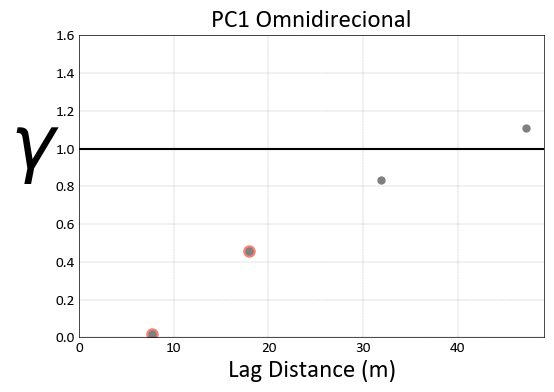

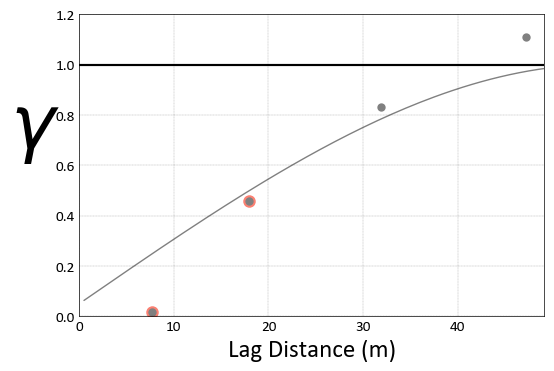

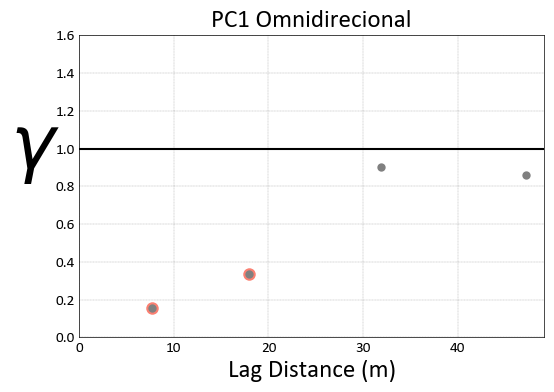

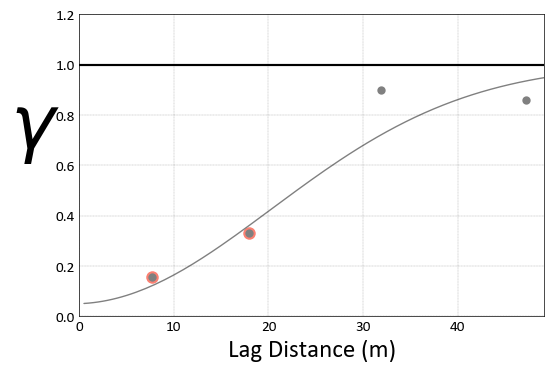

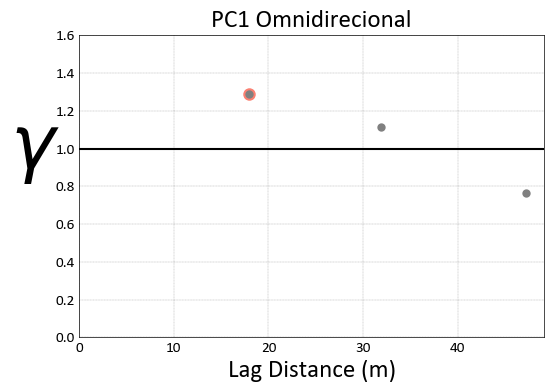

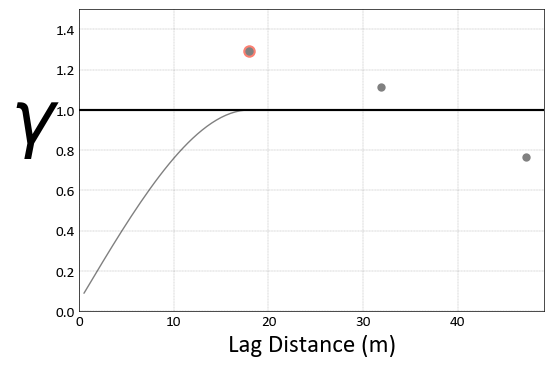

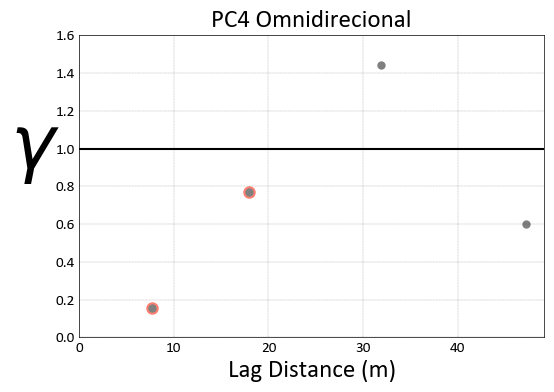

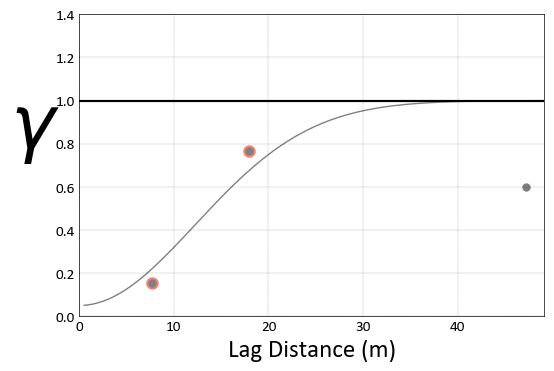

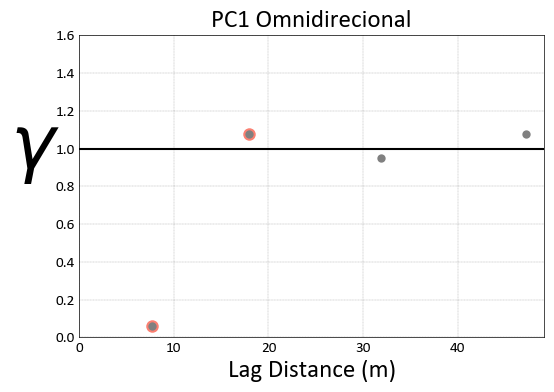

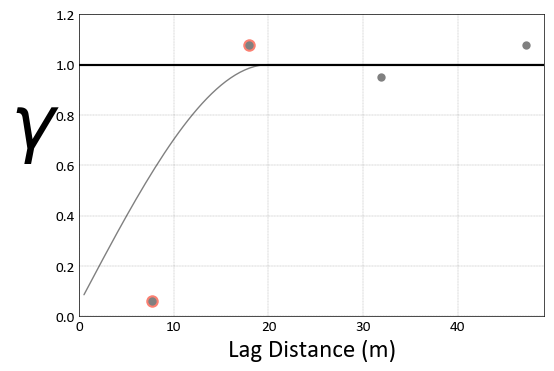

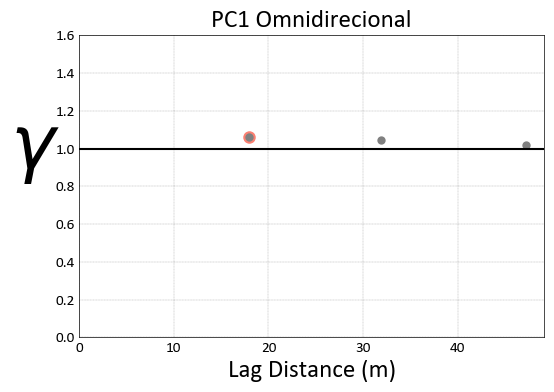

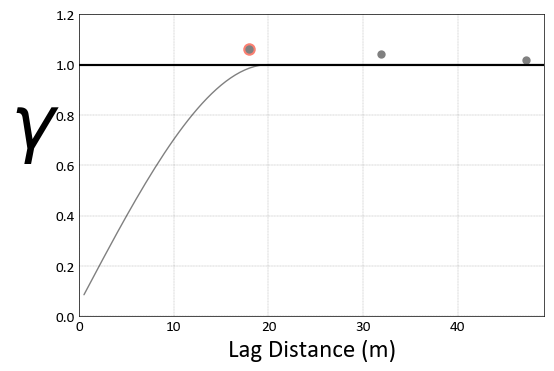

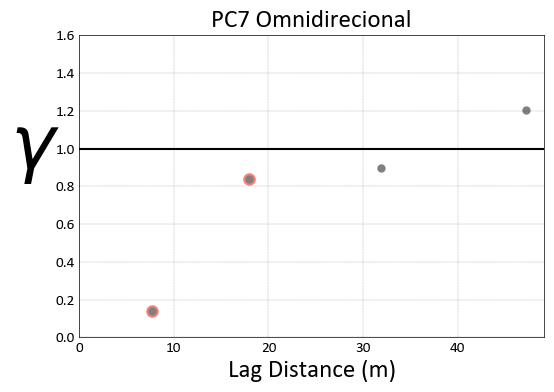

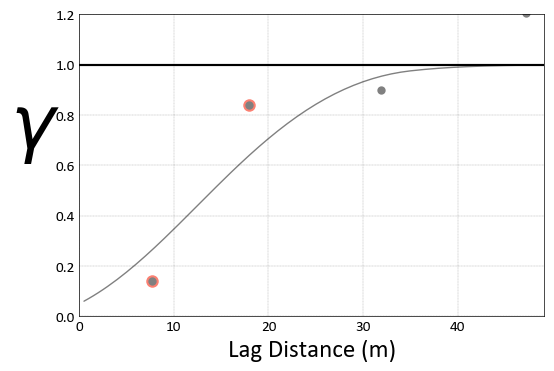

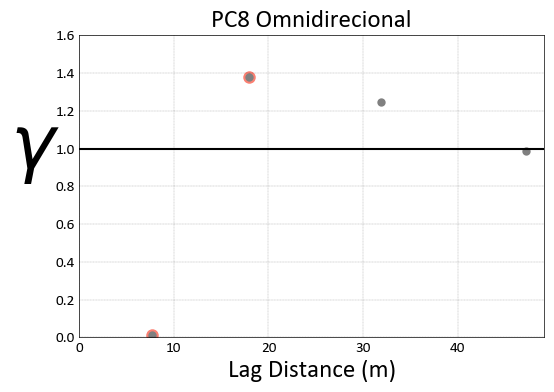

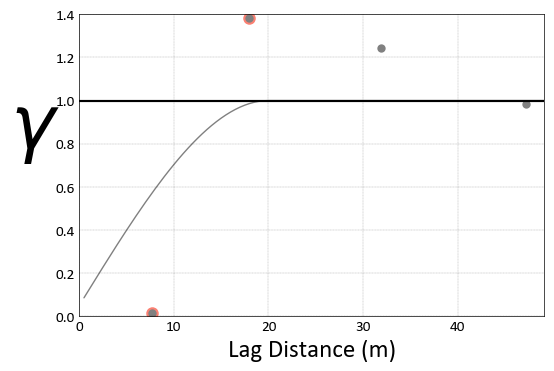

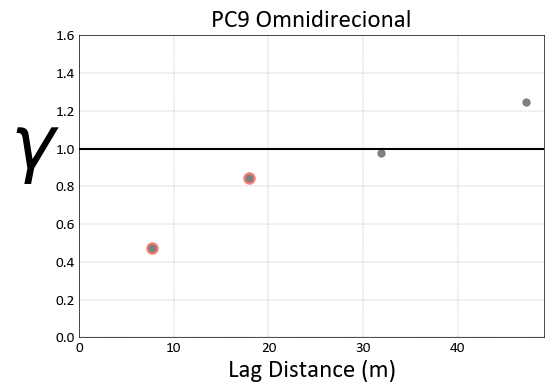

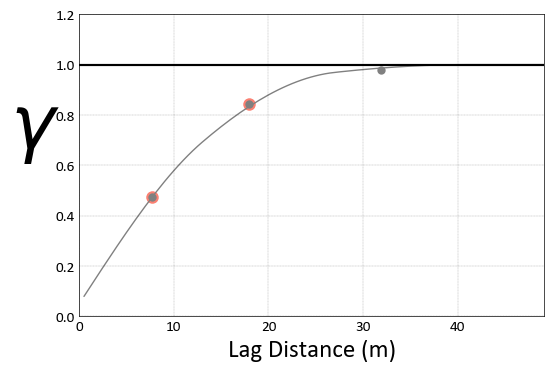

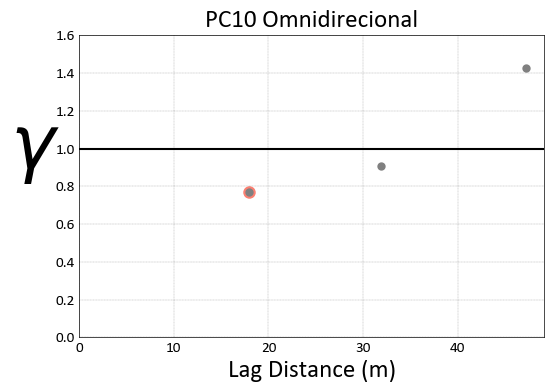

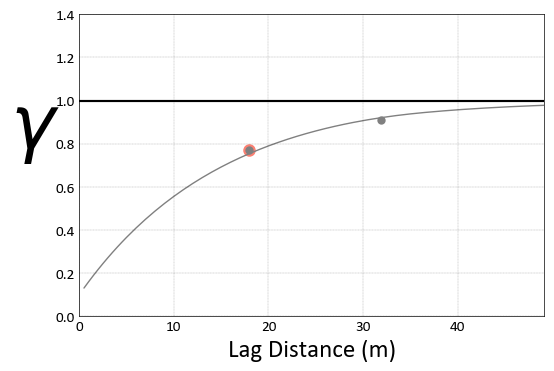

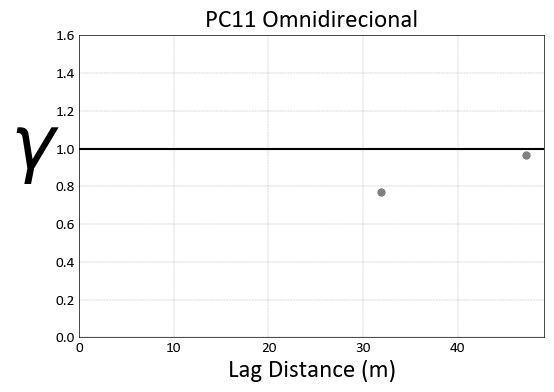

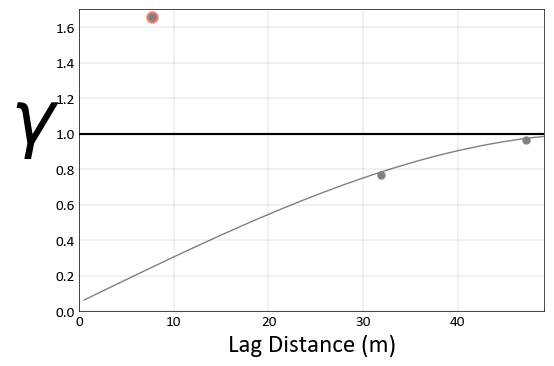

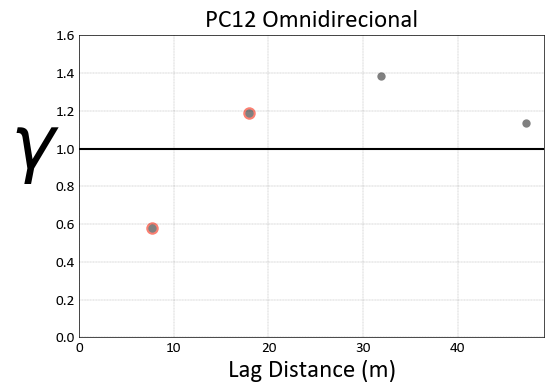

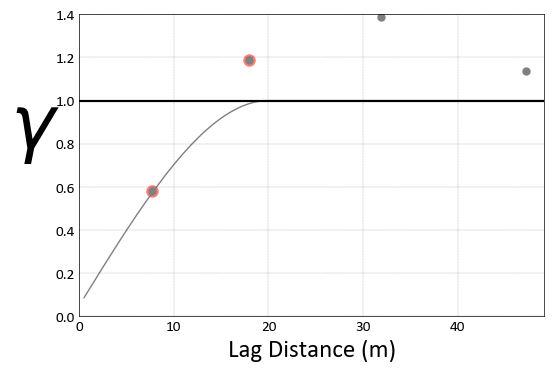

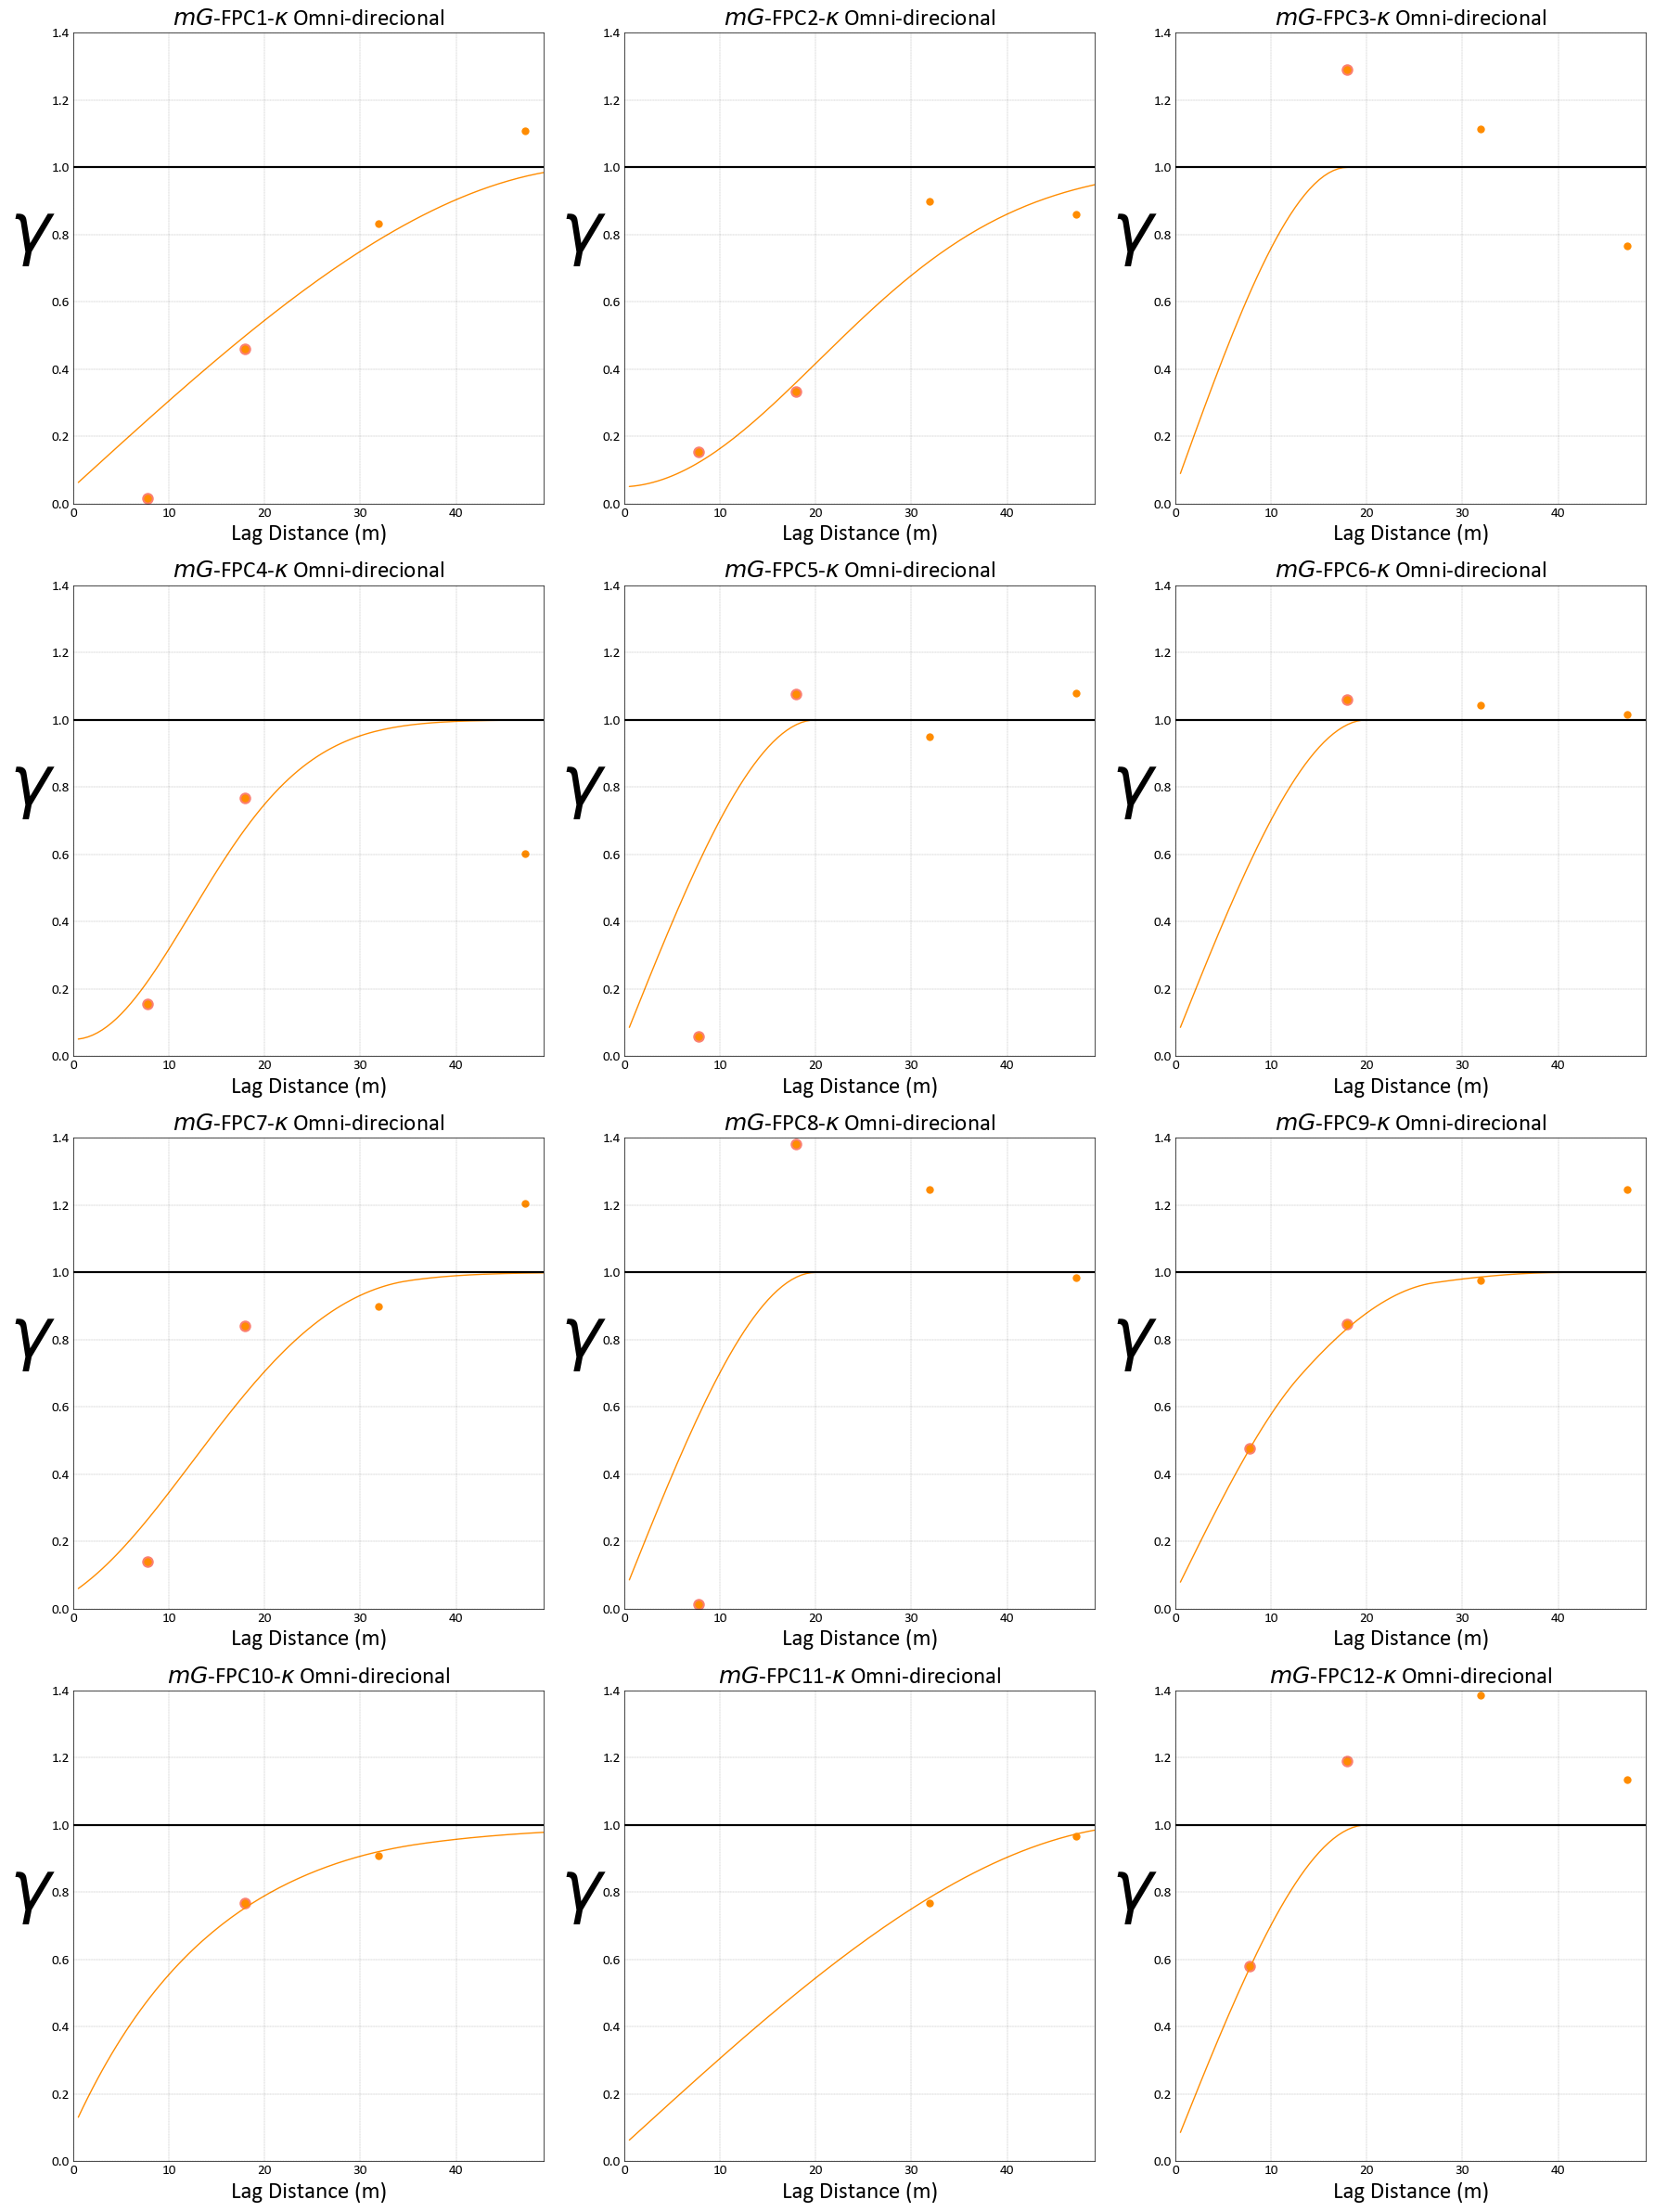

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(18, 24))  # Create a 4x3 subplot matrix



# Loop over PCs
for i in range(12):
    row = i // 3  # Calculate row index for current subplot
    col = i % 3   # Calculate column index for current subplot
    
    exp_varg = exp_vargs[i]      # Experimental variogram for current PC
    model_varg = model_vargs[i]  # Modeled variogram for current PC
    
    # Plot experimental variogram
    gs.variogram_plot(exp_varg, index=1, grid=True, sill=1, ylim=[0, 1.4], label='Experimental', 
                      title=f'$mG$-FPC{i+1} Omni-direcional', color=color_perm, ax=axs[row, col])
    
    # Plot modeled variogram
    gs.variogram_plot(model_varg, index=1, grid=True, sill=1, experimental=False, ylim=[0, 1.4], label='Model', 
                      title=f'$mG$-FPC{i+1}-$\kappa$ Omni-direcional', color=color_perm, ax=axs[row, col])

plt.tight_layout()  
plt.savefig(f'{path}perm_vars.eps', format='eps', dpi=600) 
plt.savefig(f'{path}perm_vars.tif', format='tiff', dpi=300)  

plt.show()      
